<a href="https://colab.research.google.com/github/Sng43/atari-dqn/blob/main/breakout_play_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Play.py DQN Evaluation

**Import Required Libraries**

In [14]:
import time
import os
import ale_py
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

!pip install stable-baselines3

gym.register_envs(ale_py)

from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack

**Define Environment and Model Settings**

The cell below defines the Atari environment name, saved model path, number of episodes, and frame delay so evaluation matches training and displays readable gameplay inside the notebook.

In [43]:
ENV_ID = "ALE/Breakout-v5"
MODEL_PATH = "/content/drive/MyDrive/final_model"
N_EPISODES = 5
SLEEP_TIME = 0.01

**Check and Load the Saved Model**

The cell below checks that the trained model file exists, then loads it with Stable Baselines3 so the previously trained DQN agent can be evaluated without retraining.

In [44]:
from google.colab import drive
drive.mount('/content/drive')

if not os.path.exists(MODEL_PATH + ".zip"):
    raise FileNotFoundError(
        f"Model not found: {MODEL_PATH}.zip\n"
        "Check the exact Google Drive folder and filename."
    )

model = DQN.load(MODEL_PATH)
print(f"Loaded model from {MODEL_PATH}.zip")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded model from /content/drive/MyDrive/final_model.zip


**Create the DQN-Compatible Evaluation Environment**

The cell below creates an Atari environment with rgb array rendering and applies frame stacking so the observation structure matches the trained DQN model requirements.

In [45]:
env = make_atari_env(
    ENV_ID,
    n_envs=1,
    seed=42,
    env_kwargs={"render_mode": "rgb_array"}
)

env = VecFrameStack(env, n_stack=4)

**Run Greedy DQN Evaluation and Display Frames**

The cell below runs the trained DQN agent using deterministic greedy actions, displays rendered gameplay frames in the notebook, and prints each episode’s total reward after completion.

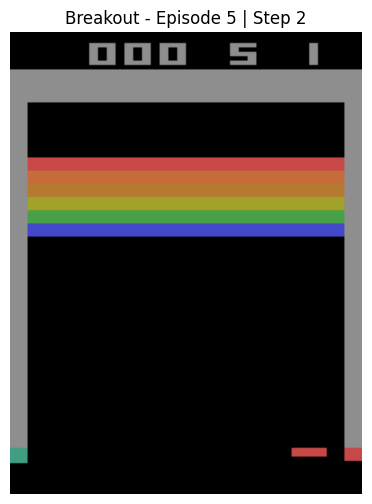

Episode 5 finished: Total Reward = 0.0

Final Episode Reward Summary:
Episode 1: 6.0
Episode 2: 0.0
Episode 3: 3.0
Episode 4: 2.0
Episode 5: 0.0


In [46]:
episode_rewards = []

# Separate environment only for display
display_env = gym.make(ENV_ID, render_mode="rgb_array")

for episode in range(1, N_EPISODES + 1):
    print(f"Starting Episode {episode}...")

    obs = env.reset()
    raw_obs, raw_info = display_env.reset()
    done = [False]
    total_reward = 0.0
    step_count = 0

    while not done[0]:
        action, _ = model.predict(obs, deterministic=True)

        # Step both environments with the same action
        obs, reward, done, info = env.step(action)
        raw_obs, raw_reward, raw_done, raw_truncated, raw_info = display_env.step(int(action[0]))
        total_reward += reward[0]
        step_count += 1

        frame = display_env.render()
        clear_output(wait=True)
        plt.figure(figsize=(8, 6))
        plt.imshow(frame)
        plt.axis("off")
        plt.title(f"Breakout - Episode {episode} | Step {step_count}")
        plt.show()

        time.sleep(SLEEP_TIME)

        if raw_done or raw_truncated:
            break

    episode_rewards.append(total_reward)
    print(f"Episode {episode} finished: Total Reward = {total_reward:.1f}")

display_env.close()

print("\nFinal Episode Reward Summary:")
for i, r in enumerate(episode_rewards, start=1):
    print(f"Episode {i}: {r:.1f}")

**Close the Environment**

The cell below vectorized Atari environment after evaluation, releasing resources properly and ending notebook rendering cleanly once all gameplay episodes are complete.

In [26]:
env.close()